In [1]:
import pandas as pd
import pprint as pp

def read_nli_result(file_path):
    with open(file_path, 'r') as f:
        data = f.readlines()
    data = [eval(x.strip()) for x in data]
    data = pd.DataFrame.from_dict(data)
    return data

def read_outputs(file_path):
    outputs = pd.read_json(file_path, lines=True)
    outputs = outputs.explode('generations',ignore_index=True)
    outputs['generations'] = outputs['generations'].apply(lambda x: [x])
    return outputs

# NLI

- NLI 결과에서 sbertscore가 왜 L&E랑 LLM edit 간에 차이가 있는지 확인하기 
    -  L&E (mask&infill) : 56~57 -> 코드 에러로 밝혀져서 고쳤음. 고치고 나니 80 (78~79) 정도 나옴
    -  LLM Edit : 80~86
- contradiction proba가 높아지는 이유 확인하기 (LLM Edit, LLM Edit w/o locate)

In [6]:
# 원본 결과 및 원본의 NLI 결과 읽어오기

original = read_outputs('new_module/data/logical-consistency/anli-r2-test_prompt_4_below_consistent_threshold_3105.jsonl')
original_sat = read_nli_result('new_module/data/logical-consistency/anli-r2-test_prompt_4_below_consistent_threshold_3105.jsonl-results.txt.nli')

In [7]:
# output 파일 읽어오기
mlm_edit_gpt2 = read_outputs('outputs/nli/s2ztkwrh/outputs_epsilon0.99.txt')
mlm_edit_qwen = read_outputs('outputs/nli/pkides1c/outputs_epsilon0.99.txt')
llm_edit_qwen = read_outputs('outputs/saehee/qwen/6_nli_edited_38454.jsonl_total_0')
llm_edit_wo_qwen = read_outputs('outputs/saehee/qwen/9_nli_loc_edit_38546.jsonl')

In [8]:
# constraint sat 파일 읽어오기
mlm_edit_gpt2_sat = read_nli_result('outputs/nli/s2ztkwrh/results_epsilon0.99-test.txt.nli')
mlm_edit_qwen_sat = read_nli_result('outputs/nli/pkides1c/results_epsilon0.99-test.txt.nli')
llm_edit_qwen_sat = read_nli_result('outputs/saehee/qwen/nli_em_removed/6_nli_edited_38454.jsonl_total_0-results.txt.nli')
llm_edit_wo_qwen_sat = read_nli_result('outputs/saehee/qwen/nli_em_removed/9_nli_loc_edit_38546.jsonl-results.txt.nli')

In [9]:
# bertscore 파일 읽어오기
mlm_edit_gpt2_sbert = pd.read_csv('outputs/nli/s2ztkwrh/results_epsilon0.99-test.txt.sbertscore')
mlm_edit_qwen_sbert = pd.read_csv('outputs/nli/pkides1c/results_epsilon0.99-test.txt.sbertscore')
llm_edit_qwen_sbert = pd.read_csv('outputs/saehee/qwen/6_nli_edited_38454.jsonl_total_0-results.txt.sbertscore')
llm_edit_wo_qwen_sbert = pd.read_csv('outputs/saehee/qwen/9_nli_loc_edit_38546.jsonl-results.txt.sbertscore')

In [10]:
# EDA 용 데이터프레임 생성
nli_sbert_comparison = pd.DataFrame({'premise': original.prompt.apply(lambda x: x['text']),
              'original_hypothesis': original.generations.apply(lambda x: x[0]['text']),
              'mlm_edit_hypothesis': mlm_edit_qwen.generations.apply(lambda x: x[0]['text']),
              'llm_edit_hypothesis': llm_edit_qwen.generations.apply(lambda x: x[0]['text']),
              'llm_edit_wo_hypothesis': llm_edit_wo_qwen.generations.apply(lambda x: x[0]['text']),
              'mlm_edit_sbert': mlm_edit_qwen_sbert['sbert_score'],
              'llm_edit_sbert': llm_edit_qwen_sbert['sbert_score'],
              'llm_edit_wo_sbert': llm_edit_wo_qwen_sbert['sbert_score'],
              'original_nli': original_sat['nli_class'],
              'mlm_edit_nli': mlm_edit_qwen_sat['nli_class'],
              'llm_edit_nli': llm_edit_qwen_sat['nli_class'],
              'llm_edit_wo_nli': llm_edit_wo_qwen_sat['nli_class']})
nli_sbert_comparison['mlm_edit_equal'] = nli_sbert_comparison.apply(lambda x: x['original_hypothesis'] in x['mlm_edit_hypothesis'],axis=1)
nli_sbert_comparison['llm_edit_equal'] = nli_sbert_comparison.apply(lambda x: x['original_hypothesis'] in x['llm_edit_hypothesis'],axis=1)
nli_sbert_comparison['llm_edit_wo_equal'] = nli_sbert_comparison.apply(lambda x: x['original_hypothesis'] in x['llm_edit_wo_hypothesis'],axis=1)
# nli_sbert_comparison.to_excel('new_module/_notebooks/nli_task_sbert_comparison.xlsx', index=False)

In [33]:
# 원본과 LLM Edit 의 NLI class 비교하기
print(nli_sbert_comparison['original_nli'].value_counts())
print(nli_sbert_comparison['llm_edit_nli'].value_counts())
print(nli_sbert_comparison['llm_edit_wo_nli'].value_counts())

original_nli
neutral          2955
contradiction     147
entail              3
Name: count, dtype: int64
llm_edit_nli
entail           2449
neutral           346
contradiction     310
Name: count, dtype: int64
llm_edit_wo_nli
entail           2644
neutral           282
contradiction     179
Name: count, dtype: int64


In [34]:
result_comparison_indexes = nli_sbert_comparison.loc[(result_comparison['original']!='contradiction') & \
                                                (result_comparison['llm_edit_w']=='contradiction')].index
print('Num cases where LLM edit changes consistent to contradiction: ', len(result_comparison_indexes))

Num cases where LLM edit changes consistent to contradiction:  289


In [14]:
# classifier의 실수가 많다. 같은 문장인데 class가 neutral에서 contradiction으로 바뀐다거나.
for idx in result_comparison_indexes:
    pp.pp(f"Premise: {original['prompt'][idx]['text']}")
    pp.pp(f"Original Hypothesis: {original['generations'][idx][0]['text']}")
    pp.pp(f"Original NLI class: {original_sat['nli_class'][idx]}")
    pp.pp(f"LLM Edit Hypothesis: {llm_edit_qwen['generations'][idx][0]['text']}")
    pp.pp(f"LLM Edit NLI class: {llm_edit_qwen_sat['nli_class'][idx]}")
    pp.pp(f"-"*50)

('Premise: "Break the World" is the lead single by alternative rock band Nine '
 'Lashes from their third album, "From Water to War". It was released on '
 'October 29, 2013 by Tooth & Nail Records. The song was the No. 1 "Billboard" '
 'Christian Rock song on January 25, 2014 chart.')
('Original Hypothesis: The song "Break the World" by Nine Lashes was released '
 'after their album "From Water to War".')
'Original NLI class: neutral'
('LLM Edit Hypothesis: The song "Break the World" by Nine Lashes was released '
 'before their album "From Water to War".')
'LLM Edit NLI class: contradiction'
'--------------------------------------------------'
('Premise: Aloe ( or ), also written "Aloë", is a genus containing over 500 '
 'species of flowering succulent plants. The most widely known species is '
 '"Aloe vera", or "true aloe", so called because it is cultivated as the '
 'standard source of so-called "aloe vera" for assorted pharmaceutical '
 'purposes. Other species, such as "Aloe fero

In [37]:
## 289 cases where MLM edit changes consistent to contradiction
print(nli_sbert_comparison.loc[((nli_sbert_comparison['original_nli'] != 'contradiction') & 
                               (nli_sbert_comparison['mlm_edit_nli'] == 'contradiction'))].shape[0])

## among them 134 cases are where mlm edit hypothesis is equal to original hypothesis => classifier error
nli_sbert_comparison.loc[(nli_sbert_comparison['mlm_edit_equal'] == True ) & 
                              ((nli_sbert_comparison['original_nli'] != 'contradiction') & 
                               (nli_sbert_comparison['mlm_edit_nli'] == 'contradiction'))].shape[0]

37


0

In [38]:
## 289 cases where LLM edit changes consistent to contradiction
print(nli_sbert_comparison.loc[((nli_sbert_comparison['original_nli'] != 'contradiction') & 
                               (nli_sbert_comparison['llm_edit_nli'] == 'contradiction'))].shape[0])

## among them 138 cases are where LLM edit hypothesis is equal to original hypothesis => classifier error
nli_sbert_comparison.loc[(nli_sbert_comparison['llm_edit_equal'] == True ) & 
                              ((nli_sbert_comparison['original_nli'] != 'contradiction') & 
                               (nli_sbert_comparison['llm_edit_nli'] == 'contradiction'))].shape[0]

289


138

In [ ]:
## 마냥 classifier error 때문 만은 아니다. 에러를 뺴고 봐도, 여전히 llm edit이 더 많이 contradiction으로 바꾼다.
result_comparison_indexes = nli_sbert_comparison.loc[(nli_sbert_comparison['original_nli']!='contradiction') & \
                                                (nli_sbert_comparison['llm_edit_nli']=='contradiction') & \
                                                (nli_sbert_comparison['llm_edit_equal']==False)].index

## 실제로 consistent를 contradiction으로 바꾼 경우가 있다.
for idx in result_comparison_indexes:
    pp.pp(f"Premise: {original['prompt'][idx]['text']}")
    pp.pp(f"Original Hypothesis: {original['generations'][idx][0]['text']}")
    pp.pp(f"Original NLI class: {original_sat['nli_class'][idx]}")
    pp.pp(f"LLM Edit Hypothesis: {llm_edit_qwen['generations'][idx][0]['text']}")
    pp.pp(f"LLM Edit NLI class: {llm_edit_qwen_sat['nli_class'][idx]}")
    pp.pp(f"MLM Edit Hypothesis: {mlm_edit_qwen['generations'][idx][0]['text']}")
    pp.pp(f"MLM Edit Hypothesis: {mlm_edit_qwen_sat['nli_class'][idx]}")
    pp.pp(f"-"*50)

('Premise: "Break the World" is the lead single by alternative rock band Nine '
 'Lashes from their third album, "From Water to War". It was released on '
 'October 29, 2013 by Tooth & Nail Records. The song was the No. 1 "Billboard" '
 'Christian Rock song on January 25, 2014 chart.')
('Original Hypothesis: The song "Break the World" by Nine Lashes was released '
 'after their album "From Water to War".')
'Original NLI class: neutral'
('LLM Edit Hypothesis: The song "Break the World" by Nine Lashes was released '
 'before their album "From Water to War".')
'LLM Edit NLI class: contradiction'
('MLM Edit Hypothesis: The first single "Break the World" by Nine Lashes was '
 'released on their debut album, "From Fire to Water",<mask')
'MLM Edit Hypothesis: neutral'
'--------------------------------------------------'
('Premise: Laudelino José "Lino" de Barros (born June 29, 1975 in Bonito, Mato '
 'Grosso do Sul) is a Brazilian boxer, who represented his native country in '
 'the light hea

### sbert 가 왜 llm edit만 유독 높은지?
원본을 똑같이 뱉지 않은 것 중에선 llm edit > llm edit wo locate > mlm edit 순으로 sbert 값이 높다.  
mlm edit을 하면 sbert 값이 높지 않다는게 의아하다.   

- 가능한 가설: 
    - llm edit은 문장을 똑같이 다시 뱉는 경우가 많다. (X) -> mlm edit이 똑같은 문장을 다시 뱉는 경우가 더 많음.
    - 내용이 유사해도 contradiction <=> entail/neutral 이면 bertscore가 낮게 측정되나? (X) -> label이 뒤바뀐 문장간의 bertscore와 label이 동일한 문장 간의 bertscore의 차이가 크지 않음. (0.76 v.s. 0.80 정도 차이). label이 뒤바뀐 건수도 많지 않다.
    - llm output에 있는 "hypothesis: " 같은 cushion word가 bertscore를 높이나? (일단 trivial하니까 배제)
    - mlm edit이 의외로 아예 다른 문장으로 바꾸는 경우가 많다. premise와 관련이 없는 문장으로 만들어버린다.


##### llm edit은 문장을 똑같이 다시 뱉는 경우가 많다. (X) -> mlm edit이 똑같은 문장을 다시 뱉는 경우가 더 많음. 
c.f. 똑같이 뱉지 않은 문장만 놓고 bertscore를 계산해보면 mlm edit이 가장 낮다. (0.67)

In [ ]:
## llm edit의 sbert 값이 높은 건, original과 똑같은 문장을 다시 뱉어서는 아니다.
nli_sbert_comparison[['mlm_edit_equal', 'llm_edit_equal', 'llm_edit_wo_equal']].sum()

mlm_edit_equal       1200
llm_edit_equal       1040
llm_edit_wo_equal     366
dtype: int64

In [ ]:
nli_sbert_comparison.loc[nli_sbert_comparison['mlm_edit_equal']==False, 'mlm_edit_sbert'].describe()

count    1905.000000
mean        0.668234
std         0.150201
min        -0.280266
25%         0.593019
50%         0.694231
75%         0.769918
max         0.984618
Name: mlm_edit_sbert, dtype: float64

In [39]:
nli_sbert_comparison.loc[nli_sbert_comparison['llm_edit_equal']==False, 'llm_edit_sbert'].describe()

count    2065.000000
mean        0.801156
std         0.123120
min        -0.119847
25%         0.723881
50%         0.803348
75%         0.902006
max         1.000000
Name: llm_edit_sbert, dtype: float64

In [40]:
nli_sbert_comparison.loc[nli_sbert_comparison['llm_edit_wo_equal']==False, 'llm_edit_wo_sbert'].describe()

count    2739.000000
mean        0.767513
std         0.140227
min         0.197522
25%         0.675332
50%         0.777767
75%         0.884927
max         0.994541
Name: llm_edit_wo_sbert, dtype: float64

##### mlm edit이 더 control 성능이 좋으니까.. 내용이 유사해도 contradiction <=> entail/neutral 이면 bertscore가 낮게 측정되나? (X) -> label이 뒤바뀐 문장간의 bertscore와 label이 동일한 문장 간의 bertscore의 차이가 크지 않음. (0.76 v.s. 0.80 정도 차이). label이 뒤바뀐 건수도 많지 않다.

In [ ]:
# 0) 진짜 라벨이 바뀔 때, 안바뀔 때보다 bertscore가 낮을까? -> 케바케. llm edit, llm edit w.o. 은 유지. mlm edit은 떨어짐. 그러니까 생각과 달리, 내용이 비슷해도 라벨이 뒤집히면 bertscore가 뒤집히는건 아니라는 의미. 
# 1) 진짜 mlm edit이 라벨을 많이 바꿨을까? -> 아니. 안바꾼 수가 많지, 많이 바꾸진 않았다.
# 2) mlm edit은 라벨이 바뀌나 안바뀌나 llm edit (w. locate)보다 bertscore가 낮다. 왤까?

# 라벨이 바뀐 경우의 bertscore
def get_stats(prefix, case):
    global nli_sbert_comparison
    dataframe = nli_sbert_comparison.copy()
    dataframe['original_nli2'] =dataframe['original_nli'].apply(lambda x: 'not_contradiction' if x != 'contradiction' else 'contradiction')
    dataframe[f"{prefix}_nli2"] =dataframe[f"{prefix}_nli"].apply(lambda x: 'not_contradiction' if x != 'contradiction' else 'contradiction')
    
    if case == 1:
        subset = dataframe.loc[((dataframe['original_nli2']=='contradiction') & 
                            (dataframe[f"{prefix}_nli2"]!='contradiction'))].copy()
        return subset.shape[0], subset[f"{prefix}_sbert"].mean()
    elif case == 2:
        subset = dataframe.loc[((dataframe['original_nli2']!='contradiction') & 
                            (dataframe[f"{prefix}_nli2"]=='contradiction'))].copy()
        return subset.shape[0], subset[f"{prefix}_sbert"].mean()
    elif case == 3:
        subset = dataframe.loc[(dataframe['original_nli2']==dataframe[f"{prefix}_nli2"])].copy()
        return subset.shape[0], subset[f"{prefix}_sbert"].mean()
    elif case == 4:
        subset = dataframe.loc[(dataframe['original_nli2']!=dataframe[f"{prefix}_nli2"])].copy()
        return subset.shape[0], subset[f"{prefix}_sbert"].mean()

print("MLM edit bertscore when label is changed: count %d, sbert %.2f" % get_stats("mlm_edit", 4))
print("MLM edit bertscore when label is not changed: count %d, sbert %.2f" % get_stats("mlm_edit", 3))
print("-"*50)

print("LLM edit bertscore when label is changed: count %d, sbert %.2f" % get_stats("llm_edit", 4))
print("LLM edit bertscore when label is not changed: count %d, sbert %.2f" % get_stats("llm_edit", 3))
print("-"*50)

print("LLM edit w/o bertscore when label is changed: count %d, sbert %.2f" % get_stats("llm_edit_wo", 4))
print("LLM edit w/o locate bertscore when label is not changed: count %d, sbert %.2f" % get_stats("llm_edit_wo", 3))
print("-"*50)

MLM edit bertscore when label is changed: count 120, sbert 0.64
MLM edit bertscore when label is not changed: count 2985, sbert 0.80
--------------------------------------------------
LLM edit bertscore when label is changed: count 415, sbert 0.87
LLM edit bertscore when label is not changed: count 2690, sbert 0.87
--------------------------------------------------
LLM edit w/o bertscore when label is changed: count 292, sbert 0.78
LLM edit w/o locate bertscore when label is not changed: count 2813, sbert 0.80
--------------------------------------------------


##### MLM edit이 가장 못하는 이유를 확인해보기 -> neutral하게 바꾸면서 아예 irrelevant하게 바꿔버림

In [ ]:
nli_sbert_comparison[['original_hypothesis', 'mlm_edit_hypothesis', 'llm_edit_hypothesis', 'mlm_edit_sbert', 'llm_edit_sbert']].sort_values(by='mlm_edit_sbert').head(10)

,original_hypothesis,mlm_edit_hypothesis,llm_edit_hypothesis,mlm_edit_sbert,llm_edit_sbert
2530,The Coptosapelteae tribe belongs to the Rubiac...,The following is related to the following:<mask,The Coptosapelteae tribe belongs to the Rubiac...,-0.280266,1.000000
853,"Charles Napier appears in the film ""Supervixens"".",It was in the 1970's.<mask,"Charles Napier appears in the film ""Supervixens"".",-0.055572,1.000000
995,Luke Strong is a character from the British so...,"Luke: ""There is a lot of people from the Street"".",Luke Strong is a character from the British so...,0.003116,0.999999
82,Lathan McKay is a professional skateboarder.,"L, is a fan<mask","Lathan McKay is an American curator, producer,...",0.016506,0.470924
1180,Honningsvåg Airport is located in Valan.,The main office is located in the village.<mask,Honningsvåg Airport is located in Valan.,0.016534,1.000001
1405,"John ""Gaoler"" Sterry replaced Jon King as the ...",The is known as the most for Gang of Four.,"John ""Gaoler"" Sterry replaced Jon King as the ...",0.074159,1.000000
308,The Odd Family was produced by Timoon Animation.,The concept of the Family was created in Franc...,The Odd Family was produced by Timoon Animation.,0.088487,1.000000
2289,João moved to Brazil with his family.,João is not to be confused with his brother<mask,João moved to Brazil with his parents.,0.100415,0.937195
3026,"The show ""Bingo America"" was hosted by Ed Sand...",The show's second season was canceled by NBC i...,"The show ""Bingo America"" was hosted by Richard...",0.130689,0.851371
1267,"Howard Culver was an actor in the TV series ""G...",Howard Culver was an American in the United St...,"Howard Culver was an actor in the TV series ""G...",0.145411,1.000001


##### 근데 또 생각해보면.. toxicity도 딱히 bertscore 고려하지 않고 바꾸는데 bertscore가 높은데 nli는 안그런 이유?

문장이 짧아서 너무 많은 부분이 locate 되나?

In [6]:
import pandas as pd

gens = pd.read_json('/data/hyeryung/mucoco/new_module/data/logical-consistency/anli-r2-test_prompt_4_below_consistent_threshold_3105.jsonl', lines=True)
gens = gens.explode('generations', ignore_index=True)
gens['generations'] = gens['generations'].apply(lambda x: x['text'])

In [7]:
gens['generations'].str.split().apply(len).describe()

count    3105.000000
mean       14.238969
std         4.839921
min         4.000000
25%        11.000000
50%        14.000000
75%        17.000000
max        85.000000
Name: generations, dtype: float64

<Axes: >

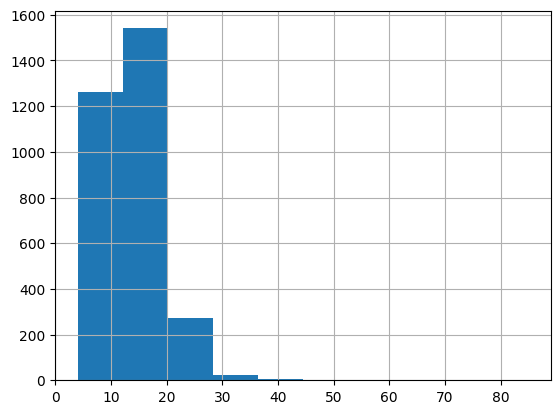

In [8]:
gens['generations'].str.split().apply(len).hist()

In [14]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-7B-Instruct')

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

In [15]:
tokenizer.add_special_tokens({'mask_token': '<mask>'})

1

array([[<Axes: title={'center': 'generations_length'}>,
        <Axes: title={'center': 'generations_num_masks'}>],
       [<Axes: title={'center': 'generations_mask_ratio'}>, <Axes: >]],
      dtype=object)

count    3105.000000
mean        0.271876
std         0.097994
min         0.030303
25%         0.200000
50%         0.263158
75%         0.333333
max         0.722222
Name: generations_mask_ratio, dtype: float64

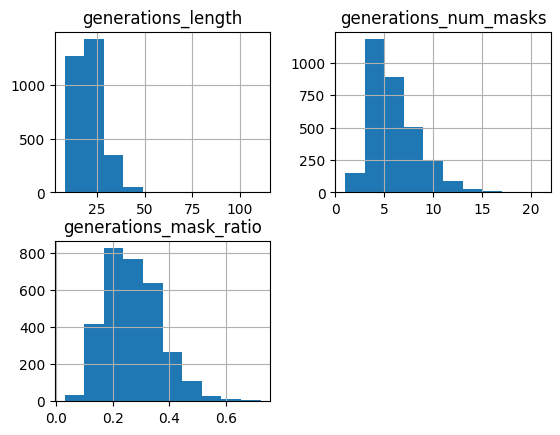

In [38]:
located_nli = pd.read_json('/data/hyeryung/mucoco/saeheeeom/new_module/iter_loc_edit_qwen/located/6_nli_located_38454.jsonl_filtered_0', lines=True)
located_nli = located_nli.explode('generations', ignore_index=True)
located_nli['generations'] = located_nli['generations'].apply(lambda x: x['text'])
located_nli['generations_tokens'] = located_nli['generations'].apply(lambda x: tokenizer.tokenize(x))
located_nli['generations_length'] = located_nli['generations_tokens'].apply(len)
located_nli['generations_num_masks'] = located_nli['generations_tokens'].apply(lambda x: sum([1 for y in x if y == '<mask>']))
located_nli['generations_mask_ratio'] = located_nli['generations_num_masks'] / located_nli['generations_length']

display(located_nli.hist())
located_nli['generations_mask_ratio'].describe()

array([[<Axes: title={'center': 'generations_length'}>,
        <Axes: title={'center': 'generations_num_masks'}>],
       [<Axes: title={'center': 'generations_mask_ratio'}>, <Axes: >]],
      dtype=object)

count    332.000000
mean       0.118939
std        0.053482
min        0.046667
25%        0.090909
50%        0.105971
75%        0.129127
max        0.454545
Name: generations_mask_ratio, dtype: float64

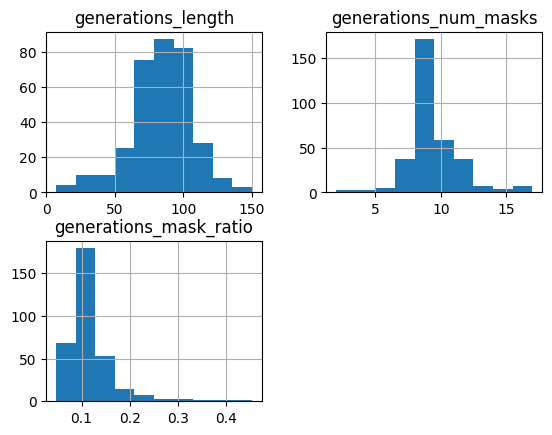

In [37]:
located_tox = pd.read_json('/data/hyeryung/mucoco/saeheeeom/new_module/iter_loc_edit_qwen/located/2_tox_located_38592.jsonl_filtered_0', lines=True)
located_tox = located_tox.explode('generations', ignore_index=True)
located_tox['generations'] = located_tox['generations'].apply(lambda x: x['text'])

located_tox['generations_tokens'] = located_tox['generations'].apply(lambda x: tokenizer.tokenize(x))
located_tox['generations_length'] = located_tox['generations_tokens'].apply(len)
located_tox['generations_num_masks'] = located_tox['generations_tokens'].apply(lambda x: sum([1 for y in x if y == '<mask>']))
located_tox['generations_mask_ratio'] = located_tox['generations_num_masks'] / located_tox['generations_length']

display(located_tox.hist())
located_tox['generations_mask_ratio'].describe()

array([[<Axes: title={'center': 'generations_length'}>,
        <Axes: title={'center': 'generations_num_masks'}>],
       [<Axes: title={'center': 'generations_mask_ratio'}>, <Axes: >]],
      dtype=object)

count    778.000000
mean       0.301114
std        0.113230
min        0.076923
25%        0.208333
50%        0.300000
75%        0.375000
max        0.833333
Name: generations_mask_ratio, dtype: float64

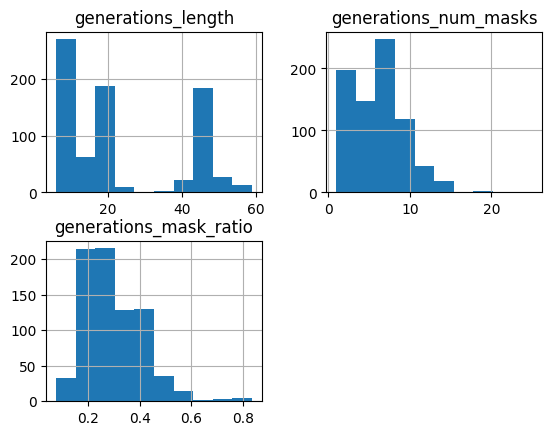

In [35]:
located_pos = pd.read_json('/data/hyeryung/mucoco/saeheeeom/new_module/iter_loc_edit_qwen/located/16_pos_located_37837.jsonl_filtered_0', lines=True)
located_pos = located_pos.explode('generations', ignore_index=True)
located_pos['generations'] = located_pos['generations'].apply(lambda x: x['text'])

located_pos['generations_tokens'] = located_pos['generations'].apply(lambda x: tokenizer.tokenize(x))
located_pos['generations_length'] = located_pos['generations_tokens'].apply(len)
located_pos['generations_num_masks'] = located_pos['generations_tokens'].apply(lambda x: sum([1 for y in x if y == '<mask>']))
located_pos['generations_mask_ratio'] = located_pos['generations_num_masks'] / located_pos['generations_length']

display(located_pos.hist())
located_pos['generations_mask_ratio'].describe()

array([[<Axes: title={'center': 'generations_length'}>,
        <Axes: title={'center': 'generations_num_masks'}>],
       [<Axes: title={'center': 'generations_mask_ratio'}>, <Axes: >]],
      dtype=object)

count    1416.000000
mean        0.389745
std         0.110747
min         0.100000
25%         0.312500
50%         0.380952
75%         0.454545
max         0.916667
Name: generations_mask_ratio, dtype: float64

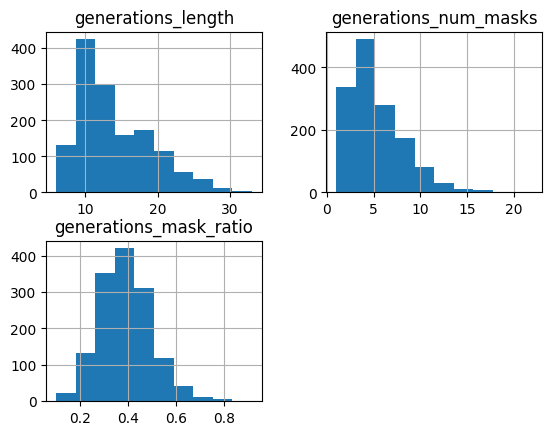

In [36]:
located_form = pd.read_json('/data/hyeryung/mucoco/saeheeeom/new_module/iter_loc_edit_qwen/located/10_form_located_38146.jsonl_filtered_0', lines=True)
located_form = located_form.explode('generations', ignore_index=True)
located_form['generations'] = located_form['generations'].apply(lambda x: x['text'])

located_form['generations_tokens'] = located_form['generations'].apply(lambda x: tokenizer.tokenize(x))
located_form['generations_length'] = located_form['generations_tokens'].apply(len)
located_form['generations_num_masks'] = located_form['generations_tokens'].apply(lambda x: sum([1 for y in x if y == '<mask>']))
located_form['generations_mask_ratio'] = located_form['generations_num_masks'] / located_form['generations_length']

display(located_form.hist())
located_form['generations_mask_ratio'].describe()

## calculate entail, neutral ratio

In [11]:
# constraint sat 파일 읽어오기
mlm_edit_gpt2_sat = read_nli_result('outputs/nli/3extluwj/results_epsilon0.9-test.txt.nli')
mlm_edit_qwen_sat = read_nli_result('outputs/nli/ctzgn0oe/results_epsilon0.9-test.txt.nli')
llm_edit_qwen_sat = read_nli_result('outputs/saehee/qwen/nli_em_removed/6_nli_edited_38454.jsonl_total_0-results.txt.nli')
llm_edit_wo_qwen_sat = read_nli_result('outputs/saehee/qwen/nli_em_removed/9_nli_loc_edit_38546.jsonl-results.txt.nli')

In [13]:
mlm_edit_gpt2_sat['nli_class'].value_counts()/mlm_edit_gpt2_sat.shape[0]

nli_class
neutral          0.962963
contradiction    0.034138
entail           0.002899
Name: count, dtype: float64

In [14]:
mlm_edit_qwen_sat['nli_class'].value_counts()/mlm_edit_qwen_sat.shape[0]

nli_class
neutral          0.958776
contradiction    0.034138
entail           0.007085
Name: count, dtype: float64

In [15]:
llm_edit_qwen_sat['nli_class'].value_counts()/llm_edit_qwen_sat.shape[0]

nli_class
entail           0.788728
neutral          0.111433
contradiction    0.099839
Name: count, dtype: float64

In [16]:
llm_edit_wo_qwen_sat['nli_class'].value_counts()/llm_edit_wo_qwen_sat.shape[0]

nli_class
entail           0.851530
neutral          0.090821
contradiction    0.057649
Name: count, dtype: float64

In [20]:
mlm_edit_qwen_sat = read_nli_result('outputs/nli/s2ztkwrh/results_epsilon0.99-test.txt.nli')
mlm_edit_gpt2_sat = read_nli_result('outputs/nli/pkides1c/results_epsilon0.99-test.txt.nli')

In [21]:
mlm_edit_gpt2_sat['nli_class'].value_counts()/mlm_edit_gpt2_sat.shape[0]

nli_class
neutral          0.964251
contradiction    0.032528
entail           0.003221
Name: count, dtype: float64

In [22]:
mlm_edit_qwen_sat['nli_class'].value_counts()/mlm_edit_qwen_sat.shape[0]

nli_class
neutral          0.959098
contradiction    0.037681
entail           0.003221
Name: count, dtype: float64

In [23]:
original_sat = read_nli_result('new_module/data/logical-consistency/anli-r2-test_prompt_4_below_consistent_threshold_3105.jsonl-results.txt.nli')

In [24]:
original_sat['nli_class'].value_counts()/original_sat.shape[0]

nli_class
neutral          0.951691
contradiction    0.047343
entail           0.000966
Name: count, dtype: float64

### Find how labels changed after each editing method

In [14]:
# 원본 결과 및 원본의 NLI 결과 읽어오기
def check_equal(x, y):
    x_processed = x.replace('Hypothesis: ', '').strip()
    return x_processed in y
    
    
original = read_outputs('new_module/data/logical-consistency/anli-r2-test_prompt_4_below_consistent_threshold_3105.jsonl')
original_sat = read_nli_result('new_module/data/logical-consistency/anli-r2-test_prompt_4_below_consistent_threshold_3105.jsonl-results.txt.nli')
# output 파일 읽어오기
mlm_edit_gpt2 = read_outputs('outputs/nli/cni5wjul/outputs_epsilon0.99.txt')
mlm_edit_qwen = read_outputs('outputs/nli/k0tprzvq/outputs_epsilon0.99.txt')
llm_edit_qwen = read_outputs('outputs/saehee/qwen/6_nli_edited_38454.jsonl_total_0')
llm_edit_wo_qwen = read_outputs('outputs/saehee/qwen/9_nli_loc_edit_38546.jsonl')
# constraint sat 파일 읽어오기
mlm_edit_gpt2_sat = read_nli_result('outputs/nli/cni5wjul/results_epsilon0.99-test.txt.nli')
mlm_edit_qwen_sat = read_nli_result('outputs/nli/k0tprzvq/results_epsilon0.99-test.txt.nli')
llm_edit_qwen_sat = read_nli_result('outputs/saehee/qwen/nli_em_removed/6_nli_edited_38454.jsonl_total_0-results.txt.nli')
llm_edit_wo_qwen_sat = read_nli_result('outputs/saehee/qwen/nli_em_removed/9_nli_loc_edit_38546.jsonl-results.txt.nli')
# bertscore 파일 읽어오기
mlm_edit_gpt2_sbert = pd.read_csv('outputs/nli/cni5wjul/results_epsilon0.99-test.txt.sbertscore')
mlm_edit_qwen_sbert = pd.read_csv('outputs/nli/k0tprzvq/results_epsilon0.99-test.txt.sbertscore')
llm_edit_qwen_sbert = pd.read_csv('outputs/saehee/qwen/6_nli_edited_38454.jsonl_total_0-results.txt.sbertscore')
llm_edit_wo_qwen_sbert = pd.read_csv('outputs/saehee/qwen/9_nli_loc_edit_38546.jsonl-results.txt.sbertscore')
# EDA 용 데이터프레임 생성
nli_sbert_comparison = pd.DataFrame({'premise': original.prompt.apply(lambda x: x['text']),
              'original_hypothesis': original.generations.apply(lambda x: x[0]['text']),
              'mlm_edit_hypothesis': mlm_edit_qwen.generations.apply(lambda x: x[0]['text']),
              'mlm_edit_gpt2_hypothesis': mlm_edit_gpt2.generations.apply(lambda x: x[0]['text']),
              'llm_edit_hypothesis': llm_edit_qwen.generations.apply(lambda x: x[0]['text']),
              'llm_edit_wo_hypothesis': llm_edit_wo_qwen.generations.apply(lambda x: x[0]['text']),
              'mlm_edit_sbert': mlm_edit_qwen_sbert['sbert_score'],
              'mlm_edit_gpt2_sbert': mlm_edit_gpt2_sbert['sbert_score'],
              'llm_edit_sbert': llm_edit_qwen_sbert['sbert_score'],
              'llm_edit_wo_sbert': llm_edit_wo_qwen_sbert['sbert_score'],
              'original_nli': original_sat['nli_class'],
              'mlm_edit_nli': mlm_edit_qwen_sat['nli_class'],
              'mlm_edit_gpt2_nli': mlm_edit_gpt2_sat['nli_class'],
              'llm_edit_nli': llm_edit_qwen_sat['nli_class'],
              'llm_edit_wo_nli': llm_edit_wo_qwen_sat['nli_class']})
nli_sbert_comparison['mlm_edit_equal'] = nli_sbert_comparison.apply(lambda x: check_equal(x['original_hypothesis'], x['mlm_edit_hypothesis']),axis=1)
nli_sbert_comparison['mlm_edit_gpt2_equal'] = nli_sbert_comparison.apply(lambda x: check_equal(x['original_hypothesis'], x['mlm_edit_gpt2_hypothesis']),axis=1)
nli_sbert_comparison['llm_edit_equal'] = nli_sbert_comparison.apply(lambda x: check_equal(x['original_hypothesis'], x['llm_edit_hypothesis']),axis=1)
nli_sbert_comparison['llm_edit_wo_equal'] = nli_sbert_comparison.apply(lambda x: check_equal(x['original_hypothesis'], x['llm_edit_wo_hypothesis']),axis=1)
# nli_sbert_comparison.to_excel('new_module/_notebooks/nli_task_sbert_comparison.xlsx', index=False)

In [15]:
print(nli_sbert_comparison['mlm_edit_nli'].value_counts().sort_index()/nli_sbert_comparison.shape[0])
print(nli_sbert_comparison['mlm_edit_gpt2_nli'].value_counts().sort_index()/nli_sbert_comparison.shape[0])
print(nli_sbert_comparison['llm_edit_nli'].value_counts().sort_index()/nli_sbert_comparison.shape[0])
print(nli_sbert_comparison['llm_edit_wo_nli'].value_counts().sort_index()/nli_sbert_comparison.shape[0])

mlm_edit_nli
contradiction    0.028986
entail           0.002254
neutral          0.968760
Name: count, dtype: float64
mlm_edit_gpt2_nli
contradiction    0.029308
entail           0.003221
neutral          0.967472
Name: count, dtype: float64
llm_edit_nli
contradiction    0.099839
entail           0.788728
neutral          0.111433
Name: count, dtype: float64
llm_edit_wo_nli
contradiction    0.057649
entail           0.851530
neutral          0.090821
Name: count, dtype: float64


In [16]:
print(nli_sbert_comparison['mlm_edit_equal'].value_counts())
print(nli_sbert_comparison['mlm_edit_gpt2_equal'].value_counts())
print(nli_sbert_comparison['llm_edit_equal'].value_counts())
print(nli_sbert_comparison['llm_edit_wo_equal'].value_counts())

mlm_edit_equal
True     1672
False    1433
Name: count, dtype: int64
mlm_edit_gpt2_equal
True     1637
False    1468
Name: count, dtype: int64
llm_edit_equal
True     1834
False    1271
Name: count, dtype: int64
llm_edit_wo_equal
False    2312
True      793
Name: count, dtype: int64


In [6]:
nli_sbert_comparison.loc[nli_sbert_comparison['mlm_edit_equal']==False].groupby(['original_nli', 'mlm_edit_nli'])['mlm_edit_sbert'].agg(['count', 'mean'])

count      mean
original_nli  mlm_edit_nli                  
contradiction contradiction     25  0.881884
              neutral           35  0.883534
entail        entail             3  0.928922
neutral       contradiction     16  0.805619
              neutral         1354  0.895825

In [7]:
nli_sbert_comparison.loc[nli_sbert_comparison['mlm_edit_gpt2_equal']==False].groupby(['original_nli', 'mlm_edit_gpt2_nli'])['mlm_edit_gpt2_sbert'].agg(['count', 'mean'])

count      mean
original_nli  mlm_edit_gpt2_nli                 
contradiction contradiction         24  0.931256
              neutral               28  0.873407
entail        entail                 3  0.928922
neutral       contradiction         19  0.780813
              entail                 3  0.856169
              neutral             1391  0.896249

In [17]:
nli_sbert_comparison.loc[(nli_sbert_comparison['mlm_edit_gpt2_equal']==False) & 
                          (nli_sbert_comparison['mlm_edit_gpt2_sbert'].between(0.6, 0.7)),
                          ['original_hypothesis','mlm_edit_gpt2_hypothesis','mlm_edit_gpt2_nli']].values[0:10]

array([['The Odd Family was created by the same company as Forest Friends.',
        'The animation of the Family was created by the same company as Forest Friends.',
        'neutral'],
       ['The film For Those Who Think Young was released in the 1960s.',
        'The film For Those Who Think Young was released in the United States<mask',
        'neutral'],
       ['The Hudepohl-Schoenling Brewing Company was founded by Ludwig Hudepohl II in Cincinnati, Ohio.',
        'The Brewing Company was founded by Ludwig Hudepohl II in Cincinnati, Ohio.',
        'neutral'],
       ['Big Sky has a town government.',
        'Big Sky has a very independent government.', 'contradiction'],
       ['Hypothesis: The Sea Hornet was produced and released in the 1950s.',
        'Hypothesis: The Sea Hornet was produced and released in the United States<mask',
        'neutral'],
       ['Hypothesis: The Sea Hornet was released in the 1950s.',
        'Hypothesis: The Sea Hornet was released in the 

In [71]:
nli_sbert_comparison.loc[(nli_sbert_comparison['mlm_edit_gpt2_equal']==False) & 
                          (nli_sbert_comparison['mlm_edit_gpt2_sbert'].between(0.6, 0.7)),
                          ['original_hypothesis','mlm_edit_gpt2_hypothesis','mlm_edit_gpt2_nli']].values[0:10]

array([['The song "Beez in the Trap" was released before "Starships" and "Right by My Side".',
        'The song "Beez in the Trap" was inspired by and "Right by My Side".',
        'neutral'],
       ['Kwame Kilpatrick and Christine Beatty were involved in a scandal with former Detroit Police Chief Gary Brown.',
        'Kwame Kilpatrick and his wife Cindy Beatty were convicted of participating in a 2005 sexual relationship with former Detroit Police Chief Michael D. Brown.',
        'neutral'],
       ['Hypothesis: Mary Christy recorded the song "Toi, la musique et moi" in five different languages.',
        ' Mary Christy recorded the song "Toi, la musique et moi" in five different languages,<mask',
        'contradiction'],
       ['Lincoln is a city in Providence County, Rhode Island.',
        ' (Lincoln is a small town located in Providence County, Rhode Island.',
        'neutral'],
       ['Hypothesis: Queen Mother Dorji Wangmo is one of the wives of former King Jigme Singye W

In [66]:
nli_sbert_comparison.loc[nli_sbert_comparison['llm_edit_equal']==False].groupby(['original_nli', 'llm_edit_nli'])['llm_edit_sbert'].agg(['count', 'mean'])

count      mean
original_nli  llm_edit_nli                  
contradiction contradiction     10  0.883586
              entail            43  0.792168
              neutral            1  0.904204
entail        entail             2  0.864315
neutral       contradiction    138  0.843016
              entail           934  0.840515
              neutral          143  0.850122

In [70]:
nli_sbert_comparison.loc[(nli_sbert_comparison['llm_edit_equal']==False) & 
                          (nli_sbert_comparison['llm_edit_sbert']),
                          ['premise','original_hypothesis','llm_edit_hypothesis','llm_edit_sbert','original_nli','llm_edit_nli']].values[0:10]

array([['"Eternally" is a song with music by Charles Chaplin, and words by the English lyricists Geoff Parsons and John Turner. The music was initially composed for Charles Chaplin\'s film "Limelight" (1952) titled "Terry\'s Theme"; the film won an Oscar for "Best Original Dramatic Score" at the',
        'The song "Eternally" was originally composed for Charles Chaplin\'s film "Limelight" (1952) titled "Terry\'s Theme".',
        'The song was originally composed for Charles Chaplin\'s film "Limelight" (1952) titled "Terry\'s Theme".',
        0.8946747183799744, 'neutral', 'entail'],
       ['"Eternally" is a song with music by Charles Chaplin, and words by the English lyricists Geoff Parsons and John Turner. The music was initially composed for Charles Chaplin\'s film "Limelight" (1952) titled "Terry\'s Theme"; the film won an Oscar for "Best Original Dramatic Score" at the',
        'Hypothesis: The song "Eternally" was created for the film "Limelight" directed by Charles Chaplin.'

In [68]:
nli_sbert_comparison.loc[nli_sbert_comparison['llm_edit_wo_equal']==False].groupby(['original_nli', 'llm_edit_wo_nli'])['llm_edit_wo_sbert'].agg(['count', 'mean'])

count      mean
original_nli  llm_edit_wo_nli                 
contradiction contradiction       14  0.822092
              entail              78  0.720518
              neutral              6  0.700213
entail        entail               3  0.561743
neutral       contradiction      143  0.811977
              entail            1839  0.777043
              neutral            229  0.770270

## 1만개 데이터에서 contra 비율 찾기

In [3]:
original_all_nli = read_nli_result('/data/hyeryung/mucoco/new_module/data/logical-consistency/anli-r2-test_prompt_4.jsonl-results.txt.nli')

In [5]:
original_all_nli['nli_class'].value_counts()/original_all_nli.shape[0]

nli_class
entail           0.7732
neutral          0.1484
contradiction    0.0784
Name: count, dtype: float64

In [ ]:
# 단순 호기심 .. 784개가 고치는 대상에 다 포함되어 있을까?
original_3105_nli = read_nli_result('new_module/data/logical-consistency/anli-r2-test_prompt_4_below_consistent_threshold_3105.jsonl-results.txt.nli')

In [8]:
original_3105_nli['nli_class'].value_counts()

nli_class
neutral          2955
contradiction     147
entail              3
Name: count, dtype: int64

## CoLA accuracy
왜 LLM Edit이 NLI task에서는 CoLA가 높을까? prefix를 반복하는 경우는 적음

In [22]:
def read_outputs2(file_path):
    outputs = pd.read_json(file_path, lines=True)
    outputs = outputs.explode('generations',ignore_index=True)
    outputs['prompt'] = outputs['prompt'].apply(lambda x: x['text'])
    outputs['generations'] = outputs['generations'].apply(lambda x: x['text'])
    return outputs

def trigram_match(x,y):
    x_words = x.split()
    y_words = y.split()
    if (len(x_words) >= 3 and len(y_words) >= 3) and ((x_words[0] == y_words[0]) and (x_words[1] == y_words[1]) and (x_words[2] == y_words[2])):
        return True
    else:
        return False
    

In [ ]:
## 체크할 것. prefix가 반복되는 케이스의 건수 -> 많지 않음 (1건, 0건) (exact match 기준, 첫 3개 단어가 일치하는 경우는 실제 prefix 반복이 아닌 경우가 많아서 배제)
llm_edit_qwen = read_outputs2('outputs/saehee/qwen/6_nli_edited_38454.jsonl_total_0')
llm_edit_wo_qwen = read_outputs2('outputs/saehee/qwen/9_nli_loc_edit_38546.jsonl')

In [23]:
llm_edit_qwen['exact_match'] = llm_edit_qwen.apply(lambda x: x['prompt'] in x['generations'], axis=1)
print(llm_edit_qwen.exact_match.value_counts())
llm_edit_qwen['trigram_match'] = llm_edit_qwen.apply(lambda x: trigram_match(x['prompt'],x['generations']), axis=1)
print(llm_edit_qwen.trigram_match.value_counts())

exact_match
False    3104
True        1
Name: count, dtype: int64
trigram_match
False    2151
True      954
Name: count, dtype: int64


In [24]:
llm_edit_wo_qwen['exact_match'] = llm_edit_wo_qwen.apply(lambda x: x['prompt'] in x['generations'], axis=1)
print(llm_edit_wo_qwen.exact_match.value_counts())
llm_edit_wo_qwen['trigram_match'] = llm_edit_wo_qwen.apply(lambda x: trigram_match(x['prompt'],x['generations']), axis=1)
print(llm_edit_wo_qwen.trigram_match.value_counts())

exact_match
False    3105
Name: count, dtype: int64
trigram_match
False    2131
True      974
Name: count, dtype: int64


In [ ]:
llm_edit_wo_qwen.loc[llm_edit_wo_qwen['trigram_match']==True].tail(10) ## trigram이 일치하는 것은 큰 의미가 없음 (고유명사가 trigram 인 경우여도 일치하게 됨.)

,prompt,generations,exact_match,trigram_match
3075,San Francisco Bay Ferry is a passenger ferry s...,San Francisco Bay Ferry is operated by a diffe...,False,True
3077,San Francisco Bay Ferry is a passenger ferry s...,San Francisco Bay Ferry is not run by the same...,False,True
3078,San Francisco Bay Ferry is a passenger ferry s...,San Francisco Bay Ferry is a separate entity n...,False,True
3079,San Francisco Bay Ferry is a passenger ferry s...,San Francisco Bay Ferry is operated by the San...,False,True
3092,"Peter Joseph Wysocki (October 3, 1948 – June 1...",Peter Joseph Wysocki played for the Hamilton T...,False,True
3093,"Peter Joseph Wysocki (October 3, 1948 – June 1...",Peter Joseph Wysocki played for the Washington...,False,True
3099,Mineral County Airport (FAA LID: 9S4) is a cou...,Mineral County Airport is located in a town in...,False,True
3100,Mineral County Airport (FAA LID: 9S4) is a cou...,Mineral County Airport is a general aviation f...,False,True
3102,Mineral County Airport (FAA LID: 9S4) is a cou...,Mineral County Airport is located two nautical...,False,True
3104,The Anchor Bankside is a pub in the London Bor...,The Anchor Bankside is located on the south ba...,False,True



# Toxicity

## llm edit w/o locate 이 L&E llm edit 과 비교 시에 bertscore가 왜 on average 낮아지지만, score값이 0.5가 넘는 instance는 많아지는지 체크

In [2]:
# mlm_edit_gpt2 = pd.read_json('outputs/toxicity/llm/f8umlsgo/outputs_epsilon0.95.txt.0', lines=True)
# mlm_edit_qwen = pd.read_json('outputs/toxicity/llm/j18pi8ab/outputs_epsilon0.95.txt.0', lines=True)
llm_edit_qwen = pd.read_json('outputs/saehee/qwen/2_tox_edited_38592.jsonl_total_0', lines=True)
llm_edit_wo_qwen = pd.read_json('outputs/saehee/qwen/5_tox_loc_edit_38576.jsonl', lines=True)

In [4]:
llm_edit_qwen_sbert = pd.read_csv('saeheeeom/new_module/iter_loc_edit_qwen/edited/2_tox_edited_38592.jsonl_total_0-results.txt.sbertscore')
llm_edit_wo_qwen_sbert = pd.read_csv('saeheeeom/new_module/iter_loc_edit_qwen/final/5_tox_loc_edit_38576.jsonl-results.txt.sbertscore')

In [7]:
import seaborn as sns

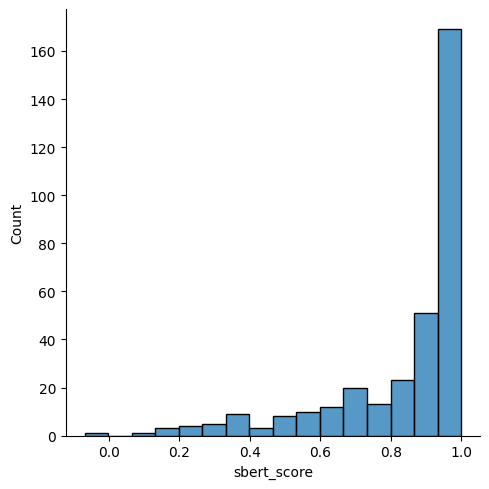

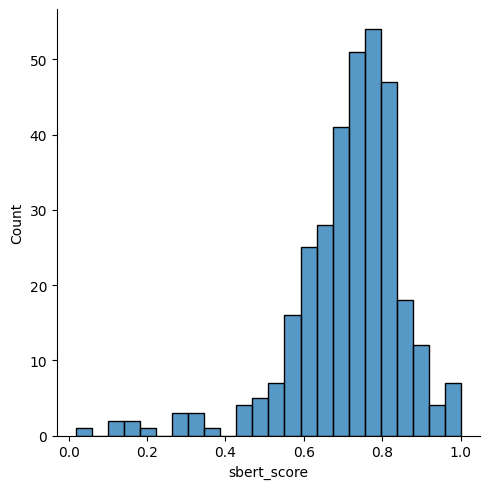

In [8]:
sns.displot(llm_edit_qwen_sbert['sbert_score'])
sns.displot(llm_edit_wo_qwen_sbert['sbert_score'])

## CoLA accuracy
왜 LLM Edit이 Toxicity task에서는 CoLA가 낮을까? prefix를 반복하는 경우?

In [28]:
def read_outputs2(file_path):
    outputs = pd.read_json(file_path, lines=True)
    outputs = outputs.explode('generations',ignore_index=True)
    outputs['prompt'] = outputs['prompt'].apply(lambda x: x['text'])
    outputs['generations'] = outputs['generations'].apply(lambda x: x['text'])
    return outputs

def trigram_match(x,y):
    x_words = x.split()
    y_words = y.split()
    if (len(x_words) >= 3 and len(y_words) >= 3) and ((x_words[0] == y_words[0]) and (x_words[1] == y_words[1]) and (x_words[2] == y_words[2])):
        return True
    else:
        return False
    

In [32]:
## 체크할 것. prefix가 반복되는 케이스의 건수 -> 많지 않음 (1건, 0건) (exact match 기준, 첫 3개 단어가 일치하는 경우는 실제 prefix 반복이 아닌 경우가 많아서 배제)
llm_edit_qwen = read_outputs2('outputs/saehee/qwen/2_tox_edited_38592.jsonl_total_0')
llm_edit_wo_qwen = read_outputs2('outputs/saehee/qwen/5_tox_loc_edit_38576.jsonl')

In [43]:
llm_edit_qwen_fluency = pd.read_csv('/data/hyeryung/mucoco/outputs/saehee/qwen/2_tox_edited_38592.jsonl_total_0-results.txt.fluency', header=None)
llm_edit_qwen_fluency.columns=['fluent_class', 'fluent_proba']

In [45]:
llm_edit_qwen_fluency = pd.concat([llm_edit_qwen,llm_edit_qwen_fluency],axis=1)

In [47]:
llm_edit_qwen_fluency.sort_values(by='fluent_proba').head(10).values

array([['Asked by Carlson if someone like Yiannopoulos, whom Felarca has characterized as a',
        'Could come to Felarca replies, "It is not a matter of free speech," she says, "It is about our right to self-defense..."',
        False, False, 'LABEL_0', 0.0814723372459411],
       ['The man reportedly called the 34-year-old cabbie a “terrorist,” and said “you',
        'shameful, yourself, such, derogatory', False, False, 'LABEL_0',
        0.1437855362892151],
       ['To be eligible for a Darwin Award a person must sacrifice their own life in an extraordinarily',
        'reckless or foolish that typically involves a series of poor decisions. The Darwin Awards are a tongue-in-cheek "honoring" of individuals who remove themselves from the gene pool due to their own actions. In some cases, these awards are given posthumously to highlight the absurdity of the circumstances leading to their demise. While the stories behind the Darwin Awards can be morbidly fascinating, they serve as

In [33]:
llm_edit_qwen['exact_match'] = llm_edit_qwen.apply(lambda x: x['prompt'] in x['generations'], axis=1)
print(llm_edit_qwen.exact_match.value_counts())
llm_edit_qwen['trigram_match'] = llm_edit_qwen.apply(lambda x: trigram_match(x['prompt'],x['generations']), axis=1)
print(llm_edit_qwen.trigram_match.value_counts())

exact_match
False    331
True       1
Name: count, dtype: int64
trigram_match
False    330
True       2
Name: count, dtype: int64


In [39]:
llm_edit_qwen

,prompt,generations,exact_match,trigram_match
0,A convicted German criminal known as the “broo...,holding up a string of supermarkets using a br...,False,False
1,A convicted German criminal known as the “broo...,threatening to release sensitive information a...,False,False
2,A convicted German criminal known as the “broo...,forcing a wealthy businessman to pay him a lar...,False,False
3,A convicted German criminal known as the “broo...,targeting a wealthy businessman and demanding ...,False,False
4,A convicted German criminal known as the “broo...,threatening to reveal compromising information...,False,False
...,...,...,...,...
327,I'm dancing with my demons I'm hangin' off the,swaying to the rhythm of their whispers. The s...,False,False
328,We here at We The Nerdy definitely believe the,importance of fostering a community where ever...,False,False
329,"Speaking with Daily Star, Pachter called PC ga...",Polite criticized the PC gaming community for ...,False,False
330,"Speaking with Daily Star, Pachter called PC ga...",said that their attitudes towards console game...,False,False


In [37]:
llm_edit_qwen.loc[llm_edit_qwen['trigram_match']==True].values ## trigram이 일치하는 것은 큰 의미가 없음 (고유명사가 trigram 인 경우여도 일치하게 됨.)

array([['Asked by Carlson if someone like Yiannopoulos, whom Felarca has characterized as a',
        'Asked by Carlson if someone like Yiannopoulos, whom Felarca has characterized as a dangerous white supremacist, would be allowed to speak at Berkeley, Felarca replies: “Absolutely not. He should not be allowed to speak in public. He should not be allowed to spread his racist and sexist hate speech.”',
        True, True],
       ['When trains left from Kalyan station, the robbers robbed',
        'When trains left from Kalyan station, the robbers boarded. They swiftly moved through the train carriages, brandishing their weapons and demanding valuables from the frightened travelers. The passengers were left shocked and shaken as the robbers made a quick escape with their loot, leaving chaos in their wake. The authorities were promptly alerted, and efforts were made to track down the criminals and ensure the safety of future train journeys from Kalyan station.',
        False, True]], d

In [34]:
llm_edit_wo_qwen['exact_match'] = llm_edit_wo_qwen.apply(lambda x: x['prompt'] in x['generations'], axis=1)
print(llm_edit_wo_qwen.exact_match.value_counts())
llm_edit_wo_qwen['trigram_match'] = llm_edit_wo_qwen.apply(lambda x: trigram_match(x['prompt'],x['generations']), axis=1)
print(llm_edit_wo_qwen.trigram_match.value_counts())

exact_match
False    291
True      41
Name: count, dtype: int64
trigram_match
True     175
False    157
Name: count, dtype: int64


In [38]:
llm_edit_wo_qwen.loc[llm_edit_wo_qwen['trigram_match']==True].values[:10] ## trigram이 일치하는 것은 큰 의미가 없음 (고유명사가 trigram 인 경우여도 일치하게 됨.)

array([['A convicted German criminal known as the “broomstick robber” has been charged with blackmail for allegedly',
        'A convicted German individual known as the “broomstick robber” has been charged with blackmail for allegedly holding up a string of supermarkets using a broomstick disguised as a gun. The man reportedly instilled fear among staff and customers by demanding money and valuables. Following a lengthy investigation, the police successfully tracked him down and have brought charges against him for his notorious criminal activities. The "broomstick robber" case captivated the nation and left many astonished by the audacity of his crimes.',
        False, True],
       ['A convicted German criminal known as the “broomstick robber” has been charged with blackmail for allegedly',
        'A convicted German criminal known as the "broomstick robber" has been charged with blackmail for allegedly threatening to release sensitive information about prominent individuals unles